In [116]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange
from geometry_tools import lerp
from conditional_gmm import ConditionalGMM
from posterior_manifold import PosteriorManifold, FisherPosteriorManifold, FisherLogPosteriorManifold
from utils import categorical_entropy, get_random_image, get_random_images, get_random_images_of_classes
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
import torch.distributions as D

transform = v2.Compose([
    v2.Resize((64, 64), interpolation=v2.InterpolationMode.BILINEAR),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
trainset = torchvision.datasets.FashionMNIST(root='datasets', transform=transform, download=True, train=True)
testset = torchvision.datasets.FashionMNIST(root='datasets', transform=transform, download=True, train=False)
dataset = torch.utils.data.ConcatDataset((trainset, testset))
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4)

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

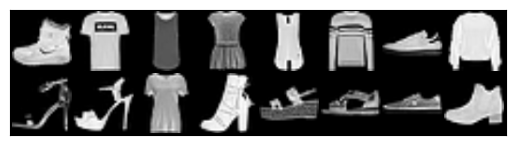

In [3]:
imgs, labels = next(dataloader.__iter__())
pullover = imgs[5]
show_img(make_grid(imgs))

/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/repos/torch_vae/model.py:288: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(fname

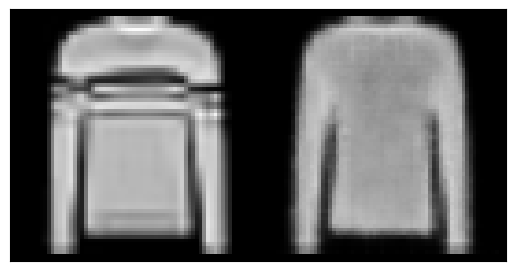

In [4]:
from pretrained_models import FashionMNIST_VAE
vae = FashionMNIST_VAE(n_latent=8)
with torch.no_grad():
    reconstructed = vae.reconstruct(pullover)
    show_img(make_grid(torch.stack((pullover, reconstructed))))

In [5]:
from matplotlib.ticker import MultipleLocator
def show_latent_curve(curve: torch.Tensor, title=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=(12, 1.25))
        ax = fig.add_subplot()
    img = make_grid(vae.decode(curve), nrow=curve.shape[0])
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray', extent=(0, 1, 0, 1/len(curve)))
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    # ax.set_xlim(0, 1)
    if title: ax.set_title(title)

In [53]:
# extracting digits separately
gmms = []
bigger_loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
for i in range(10):
    digit_samples = np.array([[], [], [], [], [], [], [], []]).T
    with torch.no_grad():
        for images, class_labels in bigger_loader:
            if torch.any(class_labels == i):
                digit_samples = np.concatenate((digit_samples, vae.encode(images[class_labels == i]).numpy()))
    new_gmm = GaussianMixture(n_components=16, covariance_type='diag',verbose=True, init_params='k-means++', max_iter=10000).fit(digit_samples)
    gmms.append(new_gmm)

Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.


In [ ]:
(gmms[0].covariances_[..., None] * np.eye(8))

array([[0.36733614, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.55177878, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.2774617 , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.51973155, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.77969278,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.97545133, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.29053692, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.37553206]])

In [70]:
gmms_torch = [D.MixtureSameFamily(
    mixture_distribution=D.Categorical(torch.as_tensor(gm.weights_, device='cuda', dtype=torch.float32)),
    component_distribution=D.MultivariateNormal(
        loc=torch.as_tensor(gm.means_, device='cuda', dtype=torch.float32),
        covariance_matrix=torch.as_tensor(gm.covariances_[..., None] * np.eye(8), device='cuda', dtype=torch.float32)
    )
) for gm in gmms]

In [71]:
digit_counts = torch.zeros(10)
for _, labels in bigger_loader:
    for i in range(10):
        digit_counts[i] += (labels == i).sum()
log_prior = (torch.log(digit_counts) - torch.log(digit_counts.sum())).cuda()

In [72]:
def log_posterior(x: torch.Tensor) -> torch.Tensor:
    cond_log_likelihoods = torch.stack([
        gm.log_prob(x) for gm in gmms_torch
    ], dim=-1) + log_prior
    return cond_log_likelihoods - torch.logsumexp(cond_log_likelihoods, dim=-1, keepdim=True)

In [73]:
M = FisherLogPosteriorManifold(log_posterior)

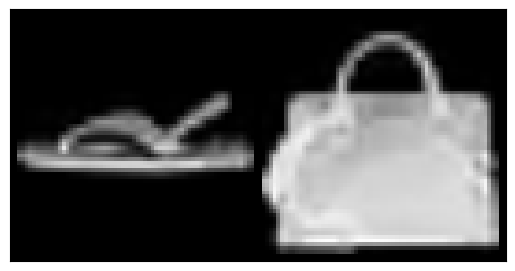

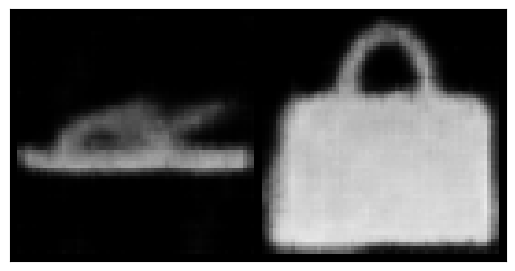

In [79]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:13<00:00, 74.86it/s, loss=0.654]


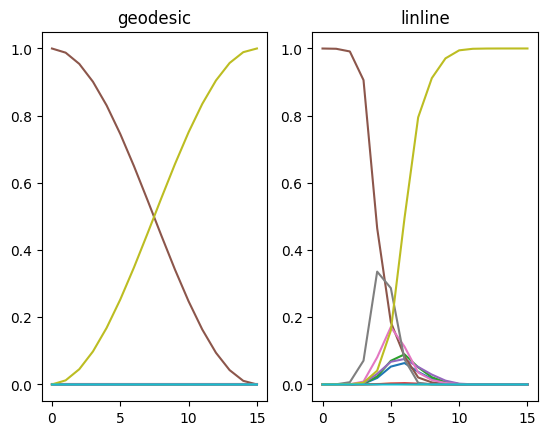

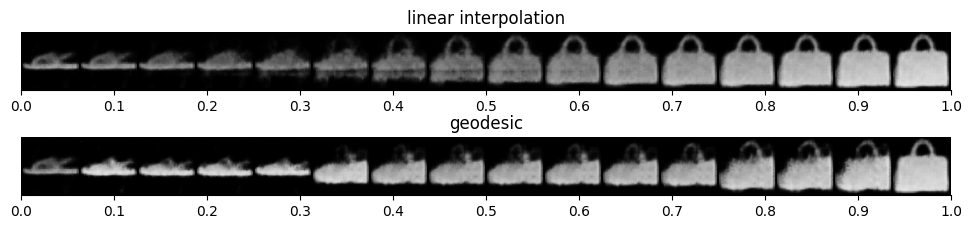

In [80]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

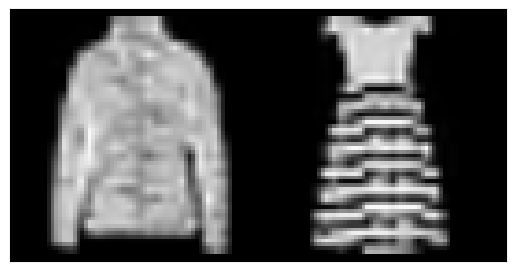

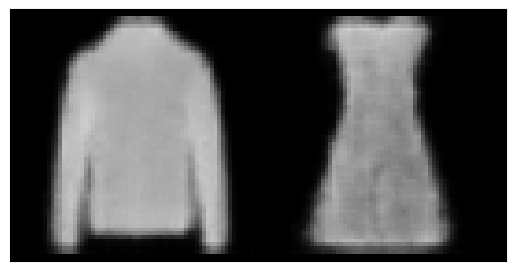

In [86]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic:   0%|          | 0/10000 [00:00<?, ?it/s, loss=2.25]

optimizing geodesic: 100%|██████████| 10000/10000 [02:11<00:00, 76.27it/s, loss=0.614]


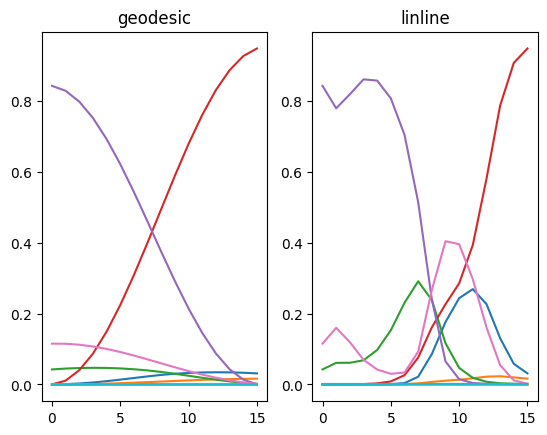

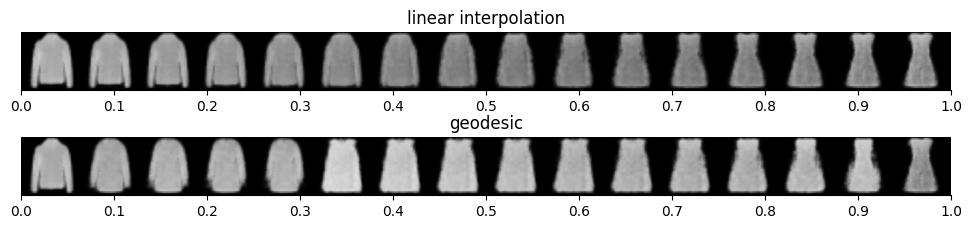

In [87]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

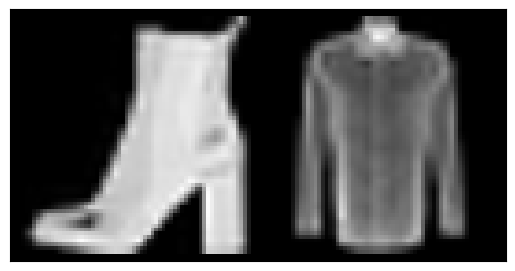

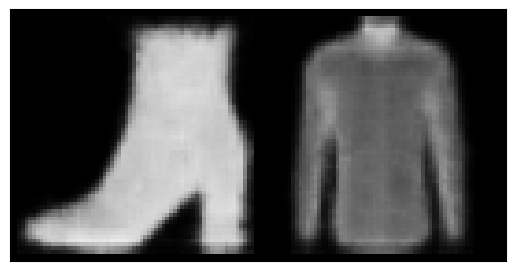

In [88]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic:   0%|          | 0/10000 [00:00<?, ?it/s]

optimizing geodesic: 100%|██████████| 10000/10000 [02:18<00:00, 71.98it/s, loss=0.835]


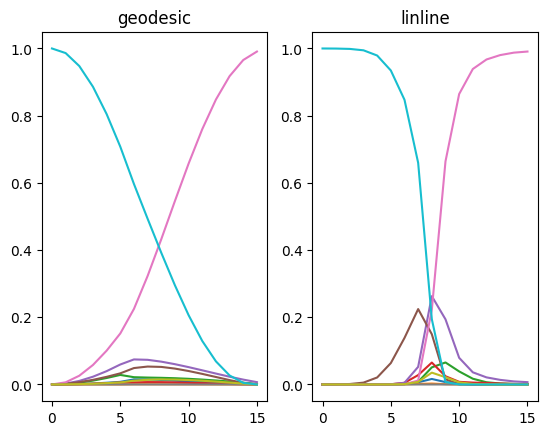

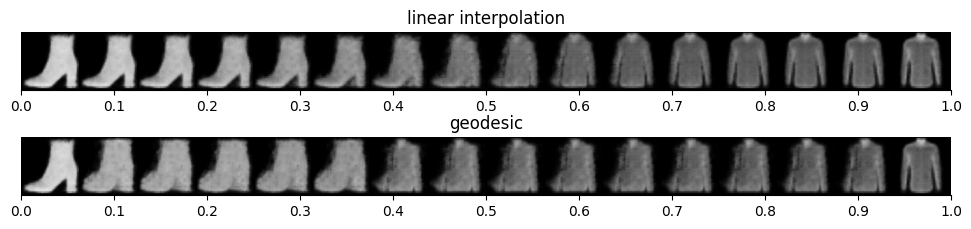

In [89]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

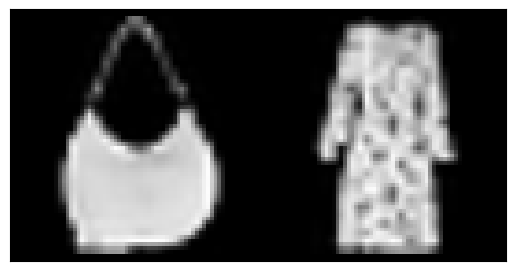

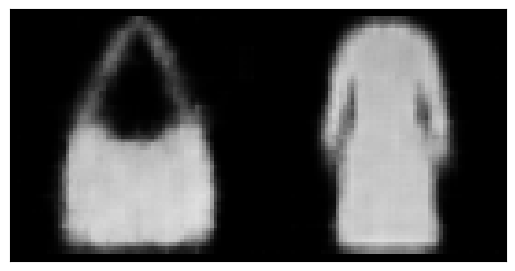

In [92]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:25<00:00, 68.82it/s, loss=0.671]


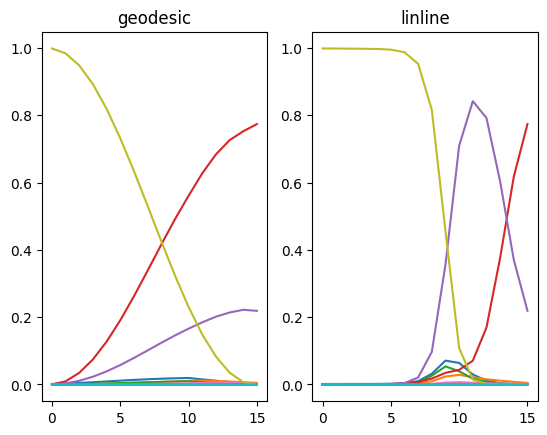

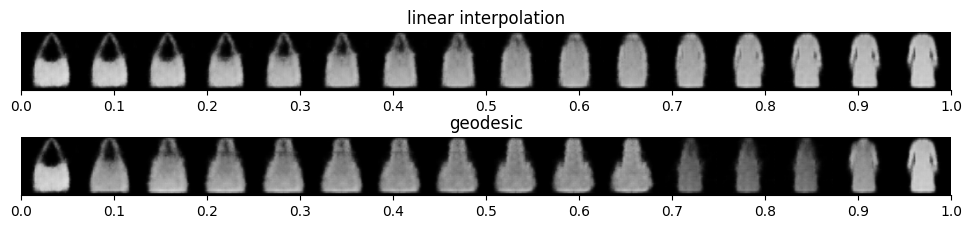

In [93]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

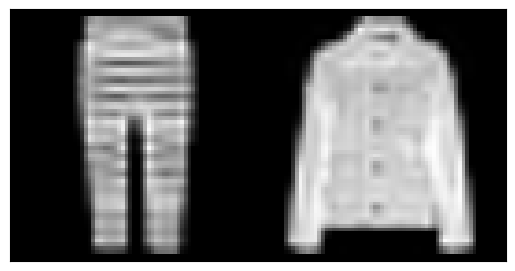

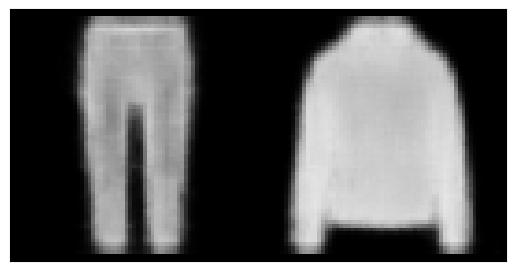

In [100]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:30<00:00, 66.47it/s, loss=0.75]


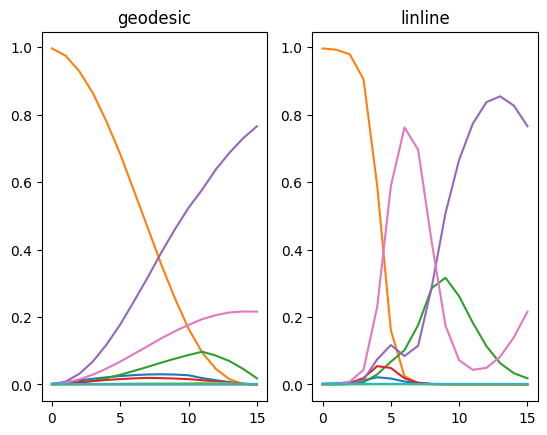

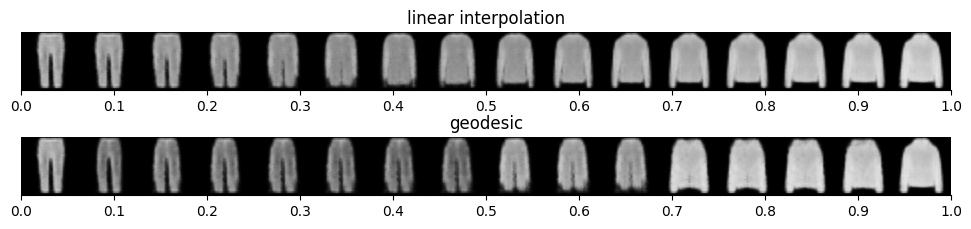

In [101]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

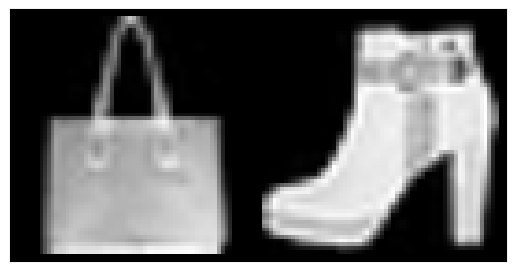

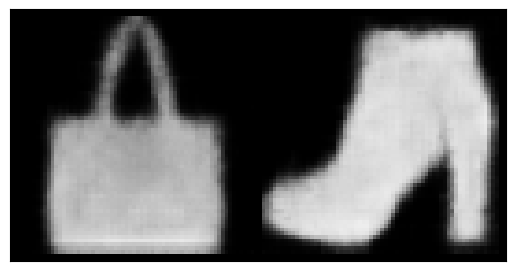

In [117]:
random_imgs = get_random_images_of_classes(dataset, [8, 9]) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:33<00:00, 64.95it/s, loss=0.656]


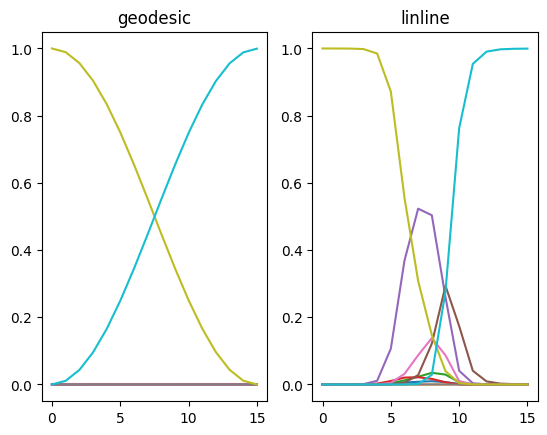

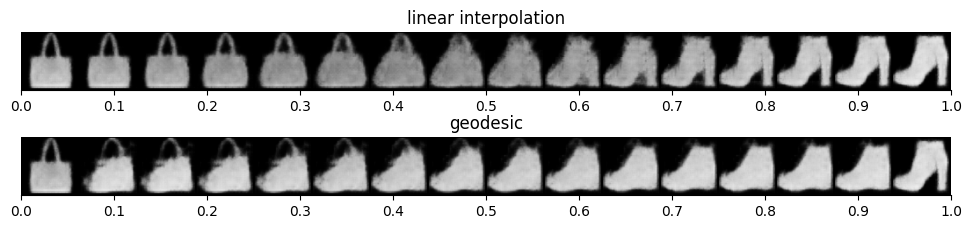

In [118]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()